# Deutsch's Algorithm and Deutsch-Jozsa Algorithm

1. [Problem Statement](#1.-Problem-Statement)
2. [Quantum Solution](#2.-Quantum-Solution)
3. [Deutsch-Jozsa](#3.-Deutsch-Jozsa)
4. [Qiskit Implementation](#4.-Qiskit-Implementation)

## 1. Problem Statement

Deutsch's algorithm is used to solve the **parity problem**: **Parity** $= f(0) \oplus f(1)$. 
Here, $\oplus$ denotes the XOR operator.

### 1.1 Example

- $f(0) = f(1)$, **Parity** = 0 (even parity, constant function)
- $f(0) \neq f(1)$, **Parity** = 1 (odd parity, balanced function)

### 1.2 Classical Solution
Classically, it takes two steps to see wether $f(0) = f(1)$, because we would have to check what $f(0)$ equals and what $f(1)$ equals. The difference quantumlly is that we can check if $f(0) = f(1)$ in only one step with phase kickback. This function is equivalent to $f(0) \oplus  f(1)$, where if $f(0) = 1$, then $f(1)$ is flipped. If $f$ is $0$, then it's constant. Otherwise, it's balanced. 

## 2. Quantum Solution

### 2.1 Quantum Circuit Explanation
![title](deutschs_images/Deutsch-solution.png)

The circuit starts with:
$$\ket{\psi_0} = \ket{01}$$
After the Hadamard gate is applied, it transforms $\ket{0} \to \ket{+}$ and $\ket{1} \to \ket{-}$. Therefore, $\ket{\psi_0} = \ket{+-}$.<br> 
To simplify, rewrite the plus state and distribute the negative state: $$\ket{\psi_1}=\frac{1}{\sqrt{2}}(\ket{0} \ket{-} + \ket{1}\ket{-})$$

Now, query the oracle $U_f$. 
$$
\ket{\psi_1}=\frac{1}{\sqrt{2}}U_f(\ket{0} \ket{-} + \ket{1}\ket{-})
\\
\ket{\psi_1}=\frac{1}{\sqrt{2}}(U_f\ket{0} \ket{-} + U_f\ket{1}\ket{-})$$

As per definition of phase oracles: $ U_f\ket{x}\ket{-} = (-1)^{f(x)}=\ket{x}\ket{-}$, plug it into the equation:
$$
\ket{\psi_2}=\frac{1}{\sqrt{2}}((-1)^{f(0)}\ket{0}) + (-1)^{f(1)}\ket{1}))
$$

Back to the parity equation:
$$
\\
f(0) = f(1):\\ \pm\frac{1}{\sqrt{2}}(\ket{0}+\ket{1}) \\ \\\pm \ket{+}
\\~\\
f(0) \neq f(1):\\ \pm\frac{1}{\sqrt{2}}(\ket{0}-\ket{1}) \\\pm \ket{-}
$$

Appying last Hadamard gate flips the plus state to zero, and minus state to one:
$$
f(0) = f(1):\\ \\\pm \ket{0}
\\~\\
f(0) \neq f(1):\\ \\\pm \ket{1}

$$

Finally, we measure the first qubit. This matches the parity problem, where:
* If we measure 0, then the function is constant: $f(0) = f(1)$
* If we measure 1, then the function is constant: $f(0) \neq f(1)$


### 2.2 IBM Quantum Composer

[Link](https://quantum.ibm.com/composer/files/new?initial=N4IgdghgtgpiBcIAiMCuAXAzgYwBYHJMACAQQBsBzAewCcBLdXKEAGhAEcJNnEB5ABQCiAOQCKJAMoBZIgCYAdAAYA3AB0wdMNjKoAJjCKqOMMnQBGARnmbsRtWHUUI6A2YhkIWmLoD6qAGZEAJ4sRAAeRMDqRETYEWGhQfYxEUnqAL7q6uw0MBRE7ADasgC69ti5%2BdiFFmXqdLoFNXVgEUWKLbhNHfZdRbX2bh5evgHdJaH9nU0D6rBcqLkzJUQAtAB8sYU96qwg%2Bjj0AA7odFRgCCAg6UA
)
![title](deutschs_images/ibmcomposer.png)

In this quantum circuit, it results in the final state of:
$$
\ket{\psi_2}=\frac{1}{\sqrt{2}}((-1)^{f(0)}\ket{0}) + (-1)^{f(1)}\ket{1}))
$$

Meaning $f(0) \oplus f(1) = 0$ if and only if we measure $\ket{0}$, and $f(0) \oplus f(1) = 1$ if and only if we measure $\ket{1}$. Therefore, we know wether the function $f(x)$ is constant or balanced.

## 3. Deutsch Jozsa

### 3.1 Parity Problem

Deutsch-Jozsa algorithm is used to solve the **parity problem**.
However, the function takes in n-bit binary values, and outputs a 0 or 1 for each input.

- $f:\{0,1\}^n = f:\{0,1\}^n, Parity = 0$ (even parity, constant function)
- $f:\{0,1\}^n \neq f:\{0,1\}^n, Parity = 0$ (even parity, constant function)

### 3.2 Quantum Circuit

The circuit is similar to Deutsch's algorithm, except at $\ket{\psi_0}$ it starts with $n$ qubits initialized to $\ket{0}$ and the final qubit is initialized to $\ket{1}$.

![title](deutschs_images/jozsa.png)

At state $\ket{\psi_1}$, a Hadamard is applied to all qubits, resulting in:
$$\frac{1}{\sqrt{2^{n+1}}} \sum_{x=0}^{2^n-1}|x\rangle(|0\rangle-|1\rangle)$$
Where $x$ runs over all $n$-bit strings.

Then, we apply the oracle, which maps $\ket{x}\ket{y}$ to $\ket{x}\ket{y \oplus f(x)}$. Because $f(x)$ can be either 0 or 1, we can simplify the $f(x)$ to:
$$\frac{1}{\sqrt{2^{n+1}}} \sum_{x=0}^{2^n-1}(-1)^{f(x)}|x\rangle(|0\rangle-|1\rangle)$$
Then, we can drop the last qubit, removing a $\frac{1}{\sqrt{2}}$  and $(\ket{0} - \ket{1})$:
$$\ket{\psi_2} = \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1}(-1)^{f(x)}|x\rangle$$

After the Hadamard is applied at $\ket{\psi_3}$, the final state is:
$$\left|\frac{1}{2^n} \sum_{x=0}^{2^n-1}(-1)^{f(x)}\right|^2$$

Meaning that the final measurement will be $\ket{0}^{\bigotimes{n}}$ (all zeroes) if $f(x)$ is constant and some other state if $f(x)$ is balanced.

## 4. Qiskit Implementation

### Imports

In [1]:
%pip install qiskit
%pip install qiskit_ibm_runtime
%pip install qiskit_aer
%pip install numpy


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import qiskit
print(qiskit.version.get_version_info())

1.0.2


### 4.1 Circuit Construction

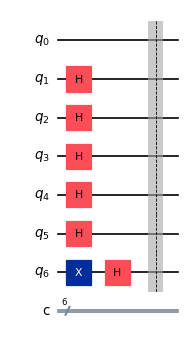

In [5]:
from qiskit import QuantumCircuit

# Preprocessing
# Select a secret bit string
n = '110101'

# Select either a constant or balanced oracle
oracle_type = 'balanced'

# Number of qubits to represent n
num_qubits = num_bits = len(n)

# Create a circuit with num_qubits + output qubit, and num_bits
qc = QuantumCircuit(num_qubits + 1, num_bits)

# Flip output qubit
qc.x(num_qubits)

# Apply Hadamards to all other qubits
qc.h(range(1, num_qubits + 1))

qc.barrier()

qc.draw(output="mpl", scale=0.6)

In [ ]:
# Oracle

if oracle_type == 'constant':
    # f(0) = f(1) returns 0 so no operation needed.
    pass  
elif oracle_type == 'balanced':
    # f(0) != f(1)
    # For every input where the first qubit is |1>, the oracle flips the target qubit.
    qc.cx(0, n)
else:
    raise ValueError("oracle_type must be either 'balanced' or 'constant'")

qc.draw(output="mpl", scale=0.6)